# Precipitation Analysis using Bias-Corrected CLIMBra Dataset

## Objective
Analyze historical precipitation patterns (1980–2013) over Brazil using bias-corrected CMIP6 data, focusing on:
- Temporal variability
- Spatial distribution
- Annual trends

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [2]:
path = "/media/mary-camila/Expansion/climbra/V5/Gridded data/pr/hist/EC-EARTH3-pr-hist.nc"

ds = xr.open_dataset(path)

ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 12419, lat: 162, lon: 168)
Coordinates:
  * time     (time) datetime64[ns] 99kB 1980-01-01T12:00:00 ... 2013-12-31T12...
  * lat      (lat) float64 1kB -34.12 -33.88 -33.62 -33.38 ... 5.625 5.875 6.125
  * lon      (lon) float64 1kB -74.12 -73.88 -73.62 ... -32.88 -32.62 -32.38
Data variables:
    pr       (time, lat, lon) float32 1GB ...
Attributes:
    creation_date:          2022-04-10
    frequency:              day
    mip_era:                CMIP6
    parent_variant_label:   r1i1p1f1
    source_id:              EC-EARTH3-
    table_id:               day
    scenario:               historical
    variable_id:            pr
    variant_label:          r1i1p1f1
    method_regrid:          Bilinear
    method_biasCorrection:  qdm-quantileDeltaMapping
    R_package_URL:          https://github.com/SantanderMetGroup/climate4R

In [3]:
print(ds)
print(ds.data_vars)
print(ds.dims)

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 12419, lat: 162, lon: 168)
Coordinates:
  * time     (time) datetime64[ns] 99kB 1980-01-01T12:00:00 ... 2013-12-31T12...
  * lat      (lat) float64 1kB -34.12 -33.88 -33.62 -33.38 ... 5.625 5.875 6.125
  * lon      (lon) float64 1kB -74.12 -73.88 -73.62 ... -32.88 -32.62 -32.38
Data variables:
    pr       (time, lat, lon) float32 1GB ...
Attributes:
    creation_date:          2022-04-10
    frequency:              day
    mip_era:                CMIP6
    parent_variant_label:   r1i1p1f1
    source_id:              EC-EARTH3-
    table_id:               day
    scenario:               historical
    variable_id:            pr
    variant_label:          r1i1p1f1
    method_regrid:          Bilinear
    method_biasCorrection:  qdm-quantileDeltaMapping
    R_package_URL:          https://github.com/SantanderMetGroup/climate4R
Data variables:
    pr       (time, lat, lon) float32 1GB ...
FrozenMappingWarningOnValuesAccess({'time': 12419, 'l

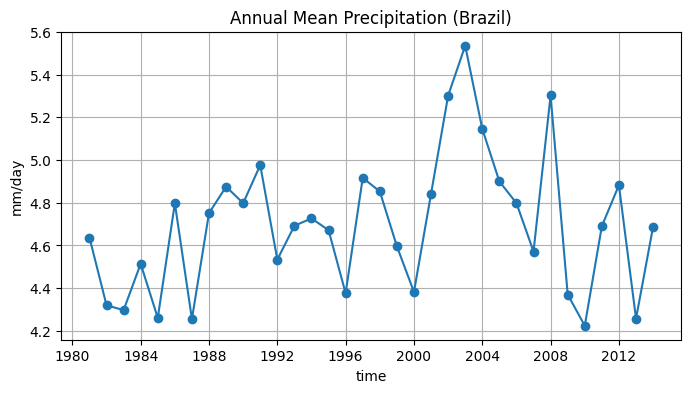

In [4]:
pr_year = ds['pr'].resample(time='YE').mean()
pr_year_mean = pr_year.mean(dim=['lat','lon'])

plt.figure(figsize=(8,4))
pr_year_mean.plot(marker='o')
plt.title("Annual Mean Precipitation (Brazil)")
plt.ylabel("mm/day")
plt.grid()
plt.show()

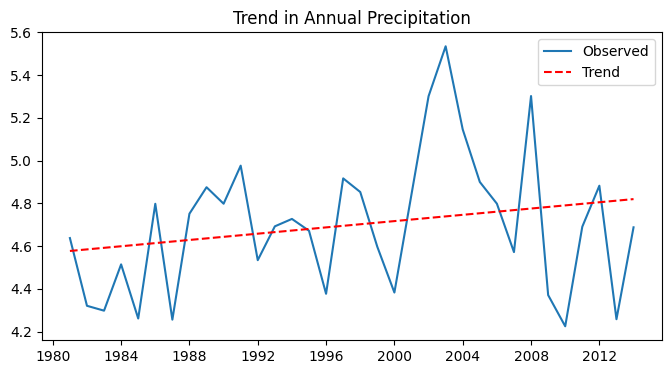

Trend (mm/day per year): 0.0073517456958092225


In [5]:
y = pr_year_mean.values
x = np.arange(len(y))

coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

plt.figure(figsize=(8,4))
plt.plot(pr_year_mean['time'], y, label="Observed")
plt.plot(pr_year_mean['time'], trend(x), 'r--', label="Trend")
plt.legend()
plt.title("Trend in Annual Precipitation")
plt.show()

print("Trend (mm/day per year):", coef[0])

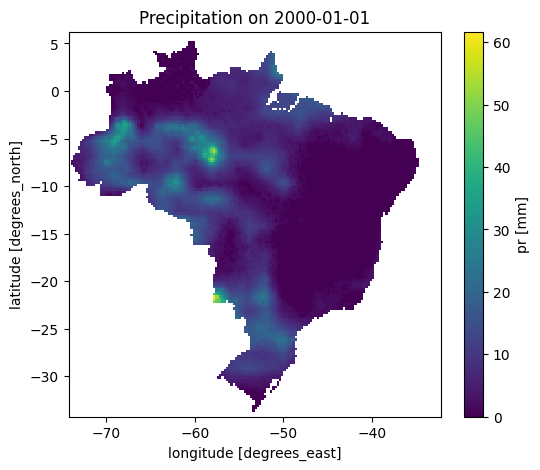

In [6]:
plt.figure(figsize=(6,5))
ds['pr'].sel(time='2000-01-01').plot()
plt.title("Precipitation on 2000-01-01")
plt.show()

In [ ]:
clim = ds['pr'].groupby('time.month').mean()

clim.mean(dim=['lat','lon']).plot(marker='o')
plt.title("Monthly Climatology of Precipitation")
plt.ylabel("mm/day")
plt.show()

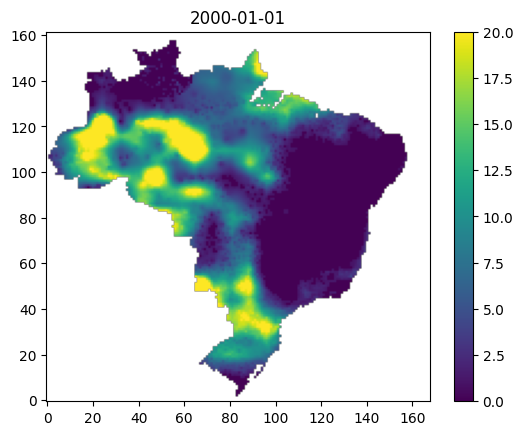

In [ ]:
ds_sel = ds.sel(time=slice("2000-01-01", "2000-02-01"))

fig, ax = plt.subplots()

# 🔹 First frame
data = ds_sel['pr'].isel(time=0)

img = ax.imshow(
    data,
    origin='lower',
    vmin=0,
    vmax=20
)

cbar = plt.colorbar(img, ax=ax)
ax.set_title(str(ds_sel['time'].values[0])[:10])

def update(frame):
    data = ds_sel['pr'].isel(time=frame)
    img.set_array(data.values)
    ax.set_title(str(ds_sel['time'].values[frame])[:10])
    return [img]

ani = animation.FuncAnimation(fig, update, frames=len(ds_sel.time))

ani.save("precip_2000.gif", writer="pillow", fps=3)